## Imports and Setup

In [1]:
import sys
sys.path.append('..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch

from src import (
    NeuralGreedy, NeuralEpsilon, NeuralUCB, NeuralThompson,
    FeaturePipeline, load_and_prepare,
    TREATMENTS, N_TREATMENTS, IDX_TO_TREATMENT,
    seed_everything, setup_plotting, timer, save_results,
    TREATMENT_COLORS, ensure_dirs,
)
from src.utils import plot_training_loss

seed_everything(42)
setup_plotting()
ensure_dirs()

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")
print(f"PyTorch: {torch.__version__}")
print("Setup complete")

Device: cpu
PyTorch: 2.8.0+cpu
Setup complete


## Load Data and Scaled Pipeline

In [2]:
df = pd.read_csv("../data/bandit_dataset.csv")

# Load the pre-fitted scaled pipeline
pipe = FeaturePipeline.load("../models/feature_pipeline_scaled.joblib")

# Split data and transform using the loaded pipeline
from sklearn.model_selection import train_test_split
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df["action"])

X_train = pipe.transform(train_df)
X_test = pipe.transform(test_df)

meta = {
    "a_train": train_df["action"].values,
    "a_test": test_df["action"].values,
    "y_train": train_df["reward"].values,
    "y_test": test_df["reward"].values,
    "cf_train": train_df[[f"reward_{i}" for i in range(N_TREATMENTS)]].values,
    "cf_test": test_df[[f"reward_{i}" for i in range(N_TREATMENTS)]].values,
    "opt_train": train_df["optimal_action"].values,
    "opt_test": test_df["optimal_action"].values,
    "feature_names": pipe.features,
}

input_dim = X_train.shape[1]

print(f"Train: {X_train.shape}")
print(f"Test:  {X_test.shape}")
print(f"Input dim: {input_dim}")
print(f"Pipeline loaded from saved scaler ✓")

C:\Users\Administrator\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
C:\Users\Administrator\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


## Train NeuralGreedy (Baseline — No Exploration)

In [3]:
print("=" * 60)
print("TRAINING: NeuralGreedy (pure exploitation)")
print("=" * 60)

greedy_bandit = NeuralGreedy(
    input_dim=input_dim,
    hidden_dims=[128, 64],
    dropout=0.1,
    lr=1e-3,
    weight_decay=1e-4,
    device=device,
)

with timer("NeuralGreedy training"):
    greedy_history = greedy_bandit.train(
        X_train, meta['a_train'], meta['y_train'],
        epochs=80,
        val_fraction=0.1,
        early_stopping_patience=10,
        verbose=True,
    )

2026-03-13 07:25:26.940 | INFO     | src.utils:timer:437 - [TIMER] NeuralGreedy training: 31.17s


## NeuralGreedy — Training Curves

In [4]:
fig = plot_training_loss(
    greedy_history['train_losses'],
    greedy_history['val_losses'],
    title="NeuralGreedy — Training Loss",
    save_path="../results/neural_greedy_loss.png",
)
plt.show()

print(f"Best val loss: {greedy_history['best_val_loss']:.4f}")
print(f"Epochs run: {greedy_history['epochs_run']}")

Best val loss: 0.5176
Epochs run: 80


## NeuralGreedy — Evaluation

In [5]:
greedy_eval = greedy_bandit.evaluate(
    X_test,
    counterfactuals=meta['cf_test'],
    optimal_actions=meta['opt_test'],
)

print("NeuralGreedy Results:")
for k, v in greedy_eval.items():
    print(f"  {k:<25} {v}")

NeuralGreedy Results:
  policy_value              5.9653
  oracle_value              6.0344
  regret                    0.0691
  accuracy                  0.878
  pct_Metformin             0.304
  pct_GLP-1                 0.1888
  pct_SGLT-2                0.261
  pct_DPP-4                 0.1668
  pct_Insulin               0.0795


## Train NeuralEpsilon (Epsilon-Greedy Exploration)

In [6]:
print("=" * 60)
print("TRAINING: NeuralEpsilon (epsilon=0.1, decay=0.995)")
print("=" * 60)

eps_bandit = NeuralEpsilon(
    input_dim=input_dim,
    hidden_dims=[128, 64],
    dropout=0.1,
    lr=1e-3,
    epsilon=0.1,
    epsilon_decay=0.995,
    epsilon_min=0.01,
    device=device,
)

with timer("NeuralEpsilon training"):
    eps_history = eps_bandit.train(
        X_train, meta['a_train'], meta['y_train'],
        epochs=80,
        val_fraction=0.1,
        early_stopping_patience=10,
    )

eps_eval = eps_bandit.evaluate(
    X_test, counterfactuals=meta['cf_test'], optimal_actions=meta['opt_test'],
)

print("\nNeuralEpsilon Results:")
for k, v in eps_eval.items():
    print(f"  {k:<25} {v}")



NeuralEpsilon Results:
  policy_value              5.9235
  oracle_value              6.0344
  regret                    0.1109
  accuracy                  0.8738
  pct_Metformin             0.3008
  pct_GLP-1                 0.1835
  pct_SGLT-2                0.2652
  pct_DPP-4                 0.1715
  pct_Insulin               0.079


## Train NeuralUCB (Upper Confidence Bound)

In [7]:
print("=" * 60)
print("TRAINING: NeuralUCB (alpha=1.0)")
print("=" * 60)

ucb_bandit = NeuralUCB(
    input_dim=input_dim,
    hidden_dims=[128, 64],
    dropout=0.1,
    lr=1e-3,
    alpha=1.0,
    reg_lambda=1.0,
    device=device,
)

with timer("NeuralUCB training"):
    ucb_history = ucb_bandit.train(
        X_train, meta['a_train'], meta['y_train'],
        epochs=80,
        val_fraction=0.1,
        early_stopping_patience=10,
    )

# Build covariance matrices from training data
print("Building covariance matrices from training data...")
with timer("Covariance update"):
    for i in range(len(X_train)):
        ucb_bandit.update_covariance(X_train[i], int(meta['a_train'][i]))

ucb_eval = ucb_bandit.evaluate(
    X_test, counterfactuals=meta['cf_test'], optimal_actions=meta['opt_test'],
)

print("\nNeuralUCB Results:")
for k, v in ucb_eval.items():
    print(f"  {k:<25} {v}")


NeuralUCB Results:
  policy_value              5.9668
  oracle_value              6.0344
  regret                    0.0676
  accuracy                  0.8738
  pct_Metformin             0.2868
  pct_GLP-1                 0.19
  pct_SGLT-2                0.2675
  pct_DPP-4                 0.1742
  pct_Insulin               0.0815


## Train NeuralThompson (Thompson Sampling)

In [8]:
print("=" * 60)
print("TRAINING: NeuralThompson (Bayesian posterior)")
print("=" * 60)

ts_bandit = NeuralThompson(
    input_dim=input_dim,
    hidden_dims=[128, 64],
    dropout=0.1,
    lr=1e-3,
    reg_lambda=1.0,
    noise_variance=0.25,
    device=device,
)

with timer("NeuralThompson training"):
    ts_history = ts_bandit.train(
        X_train, meta['a_train'], meta['y_train'],
        epochs=80,
        val_fraction=0.1,
        early_stopping_patience=10,
    )

# Build posterior from training data
print("Building posterior from training data...")
with timer("Posterior update"):
    for i in range(len(X_train)):
        ts_bandit.update_posterior(
            X_train[i], int(meta['a_train'][i]), float(meta['y_train'][i])
        )

ts_eval = ts_bandit.evaluate(
    X_test, counterfactuals=meta['cf_test'], optimal_actions=meta['opt_test'],
)

print("\nNeuralThompson Results:")
for k, v in ts_eval.items():
    print(f"  {k:<25} {v}")


NeuralThompson Results:
  policy_value              5.9719
  oracle_value              6.0344
  regret                    0.0625
  accuracy                  0.885
  pct_Metformin             0.3015
  pct_GLP-1                 0.1832
  pct_SGLT-2                0.2648
  pct_DPP-4                 0.1722
  pct_Insulin               0.0782


## All Neural Bandits — Comparison

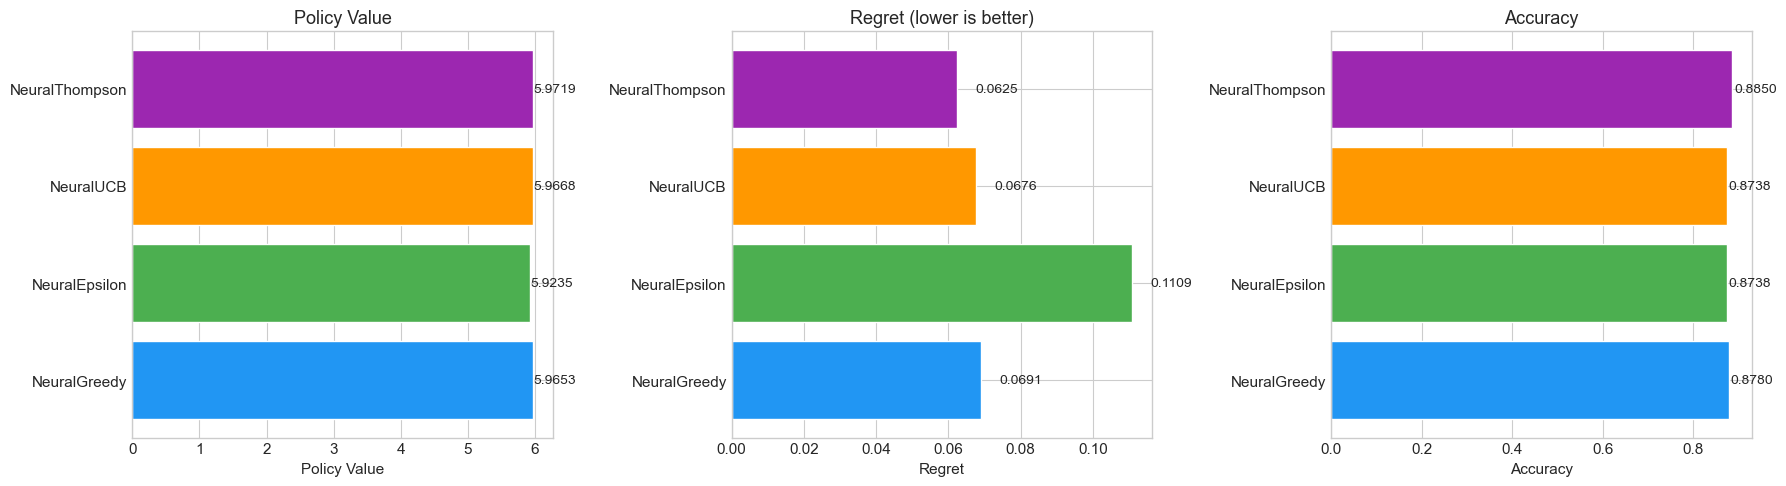

In [9]:
comparison = pd.DataFrame([
    {"model": "NeuralGreedy", **greedy_eval},
    {"model": "NeuralEpsilon", **eps_eval},
    {"model": "NeuralUCB", **ucb_eval},
    {"model": "NeuralThompson", **ts_eval},
])

print("=" * 60)
print("NEURAL BANDIT COMPARISON")
print("=" * 60)
print(comparison[['model', 'policy_value', 'regret', 'accuracy']].to_string(index=False))

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))

models = comparison['model']
colors = ['#2196F3', '#4CAF50', '#FF9800', '#9C27B0']

ax1.barh(models, comparison['policy_value'], color=colors, edgecolor='white')
ax1.set_xlabel("Policy Value")
ax1.set_title("Policy Value")
for i, v in enumerate(comparison['policy_value']):
    ax1.text(v + 0.01, i, f"{v:.4f}", va='center', fontsize=10)

ax2.barh(models, comparison['regret'], color=colors, edgecolor='white')
ax2.set_xlabel("Regret")
ax2.set_title("Regret (lower is better)")
for i, v in enumerate(comparison['regret']):
    ax2.text(v + 0.005, i, f"{v:.4f}", va='center', fontsize=10)

ax3.barh(models, comparison['accuracy'], color=colors, edgecolor='white')
ax3.set_xlabel("Accuracy")
ax3.set_title("Accuracy")
for i, v in enumerate(comparison['accuracy']):
    ax3.text(v + 0.005, i, f"{v:.4f}", va='center', fontsize=10)

plt.tight_layout()
plt.show()

## Training Loss Comparison

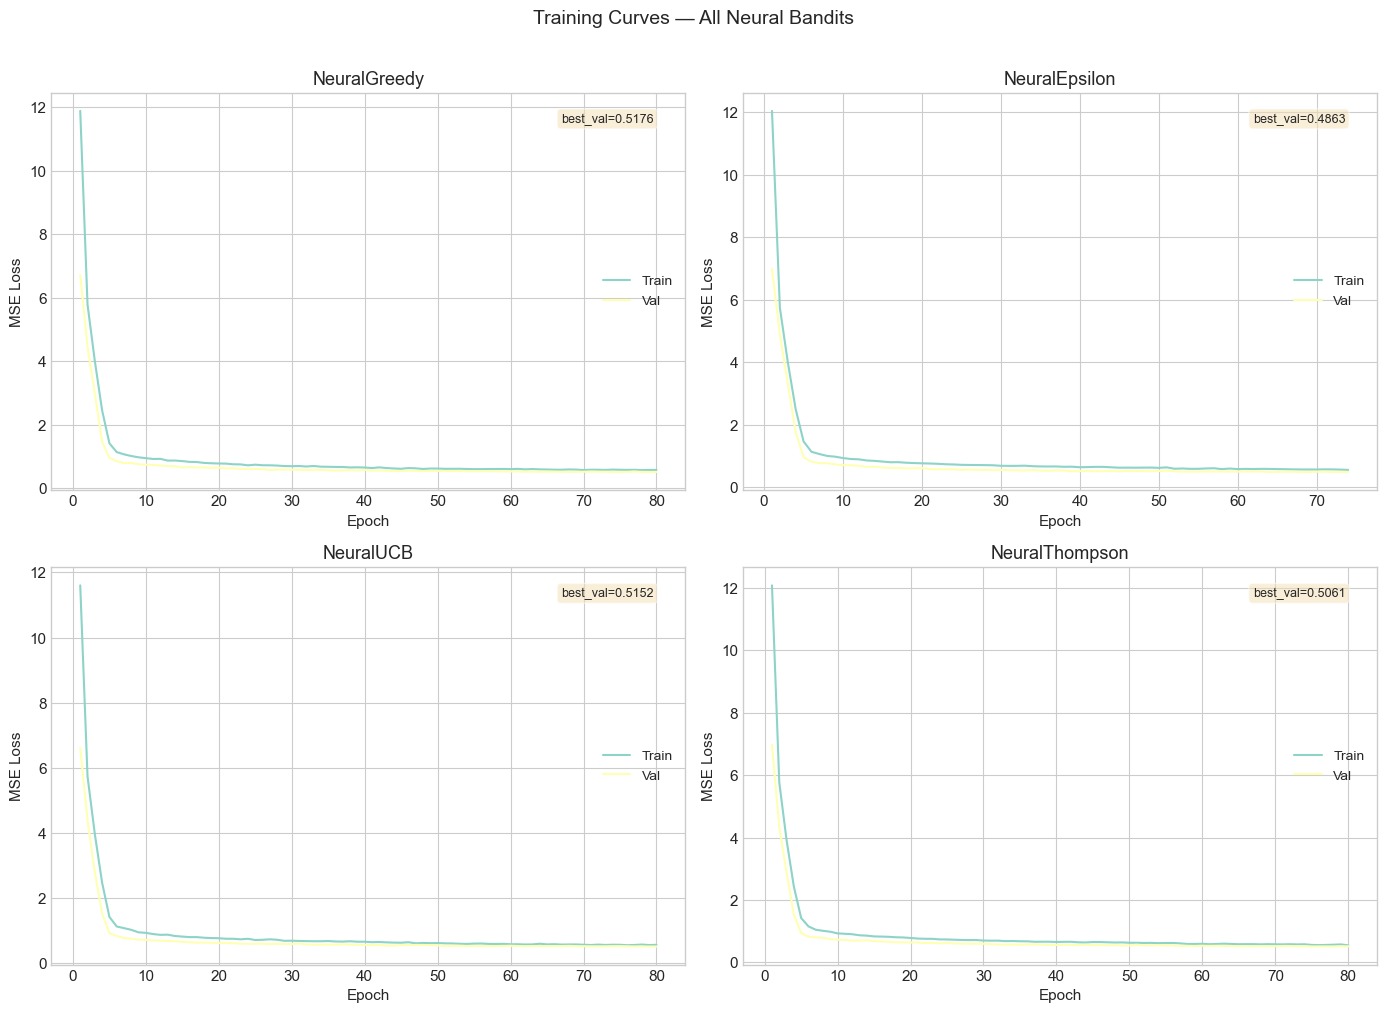

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

histories = [
    ("NeuralGreedy", greedy_history),
    ("NeuralEpsilon", eps_history),
    ("NeuralUCB", ucb_history),
    ("NeuralThompson", ts_history),
]

for ax, (name, hist) in zip(axes.flatten(), histories):
    epochs = range(1, len(hist['train_losses']) + 1)
    ax.plot(epochs, hist['train_losses'], label='Train', linewidth=1.5)
    ax.plot(epochs, hist['val_losses'], label='Val', linewidth=1.5)
    ax.set_title(name)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("MSE Loss")
    ax.legend()
    ax.text(0.95, 0.95, f"best_val={hist['best_val_loss']:.4f}",
            transform=ax.transAxes, ha='right', va='top', fontsize=9,
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.suptitle("Training Curves — All Neural Bandits", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## Action Distribution Comparison

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

bandits = [
    ("NeuralGreedy", greedy_bandit),
    ("NeuralEpsilon", eps_bandit),
    ("NeuralUCB", ucb_bandit),
    ("NeuralThompson", ts_bandit),
]

for ax, (name, bandit) in zip(axes.flatten(), bandits):
    actions = bandit.select_actions(X_test)
    counts = np.bincount(actions, minlength=N_TREATMENTS)
    opt_counts = np.bincount(meta['opt_test'], minlength=N_TREATMENTS)

    x = np.arange(N_TREATMENTS)
    w = 0.35
    ax.bar(x - w/2, counts / counts.sum(), w, label='Model', color='#2196F3', edgecolor='white')
    ax.bar(x + w/2, opt_counts / opt_counts.sum(), w, label='Oracle', color='#1565C0', edgecolor='white')
    ax.set_xticks(x)
    ax.set_xticklabels(TREATMENTS, fontsize=8)
    ax.set_ylabel("Proportion")
    ax.set_title(name)
    ax.legend(fontsize=8)

plt.suptitle("Action Distribution — Neural Bandits vs Oracle", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## Architecture Sensitivity — Hidden Dimensions

In [ ]:
print("Architecture sensitivity: hidden layer sizes")
arch_results = []

architectures = [
    ([64], "64"),
    ([128], "128"),
    ([64, 32], "64-32"),
    ([128, 64], "128-64"),
    ([256, 128], "256-128"),
    ([128, 64, 32], "128-64-32"),
    ([256, 128, 64], "256-128-64"),
]

for hidden, label in architectures:
    model = NeuralGreedy(
        input_dim=input_dim, hidden_dims=hidden,
        dropout=0.1, lr=1e-3, device=device,
    )
    hist = model.train(X_train, meta['a_train'], meta['y_train'],
                       epochs=60, verbose=False)
    ev = model.evaluate(X_test, meta['cf_test'], meta['opt_test'])

    n_params = sum(p.numel() for p in model.network.parameters())
    arch_results.append({
        "architecture": label,
        "params": n_params,
        "val_loss": hist['best_val_loss'],
        **ev,
    })
    print(f"  {label:<15} params={n_params:>7,}  "
          f"val_loss={hist['best_val_loss']:.4f}  "
          f"accuracy={ev['accuracy']:.4f}  regret={ev['regret']:.4f}")

arch_df = pd.DataFrame(arch_results)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(arch_df['params'], arch_df['accuracy'], 'o-', color='#4CAF50', linewidth=2)
ax1.set_xlabel("Number of Parameters")
ax1.set_ylabel("Accuracy")
ax1.set_title("Accuracy vs Model Size")
for _, row in arch_df.iterrows():
    ax1.annotate(row['architecture'], (row['params'], row['accuracy']),
                 textcoords="offset points", xytext=(5, 5), fontsize=8)

ax2.plot(arch_df['params'], arch_df['regret'], 'o-', color='#F44336', linewidth=2)
ax2.set_xlabel("Number of Parameters")
ax2.set_ylabel("Regret")
ax2.set_title("Regret vs Model Size")

plt.tight_layout()
plt.show()

## NeuralUCB — Alpha Sensitivity

In [ ]:
print("NeuralUCB alpha sensitivity:")
alpha_results = []

for alpha in [0.1, 0.25, 0.5, 1.0, 2.0, 5.0]:
    model = NeuralUCB(
        input_dim=input_dim, hidden_dims=[128, 64],
        lr=1e-3, alpha=alpha, device=device,
    )
    model.train(X_train, meta['a_train'], meta['y_train'], epochs=60, verbose=False)

    # Build covariance
    for i in range(min(5000, len(X_train))):
        model.update_covariance(X_train[i], int(meta['a_train'][i]))

    ev = model.evaluate(X_test, meta['cf_test'], meta['opt_test'])
    alpha_results.append({"alpha": alpha, **ev})
    print(f"  alpha={alpha:<5}: accuracy={ev['accuracy']:.4f}, regret={ev['regret']:.4f}")

alpha_df = pd.DataFrame(alpha_results)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.plot(alpha_df['alpha'], alpha_df['accuracy'], 'o-', color='#4CAF50', linewidth=2)
ax1.set_xlabel("Alpha (exploration weight)")
ax1.set_ylabel("Accuracy")
ax1.set_title("NeuralUCB — Accuracy vs Alpha")
ax1.set_xscale('log')

ax2.plot(alpha_df['alpha'], alpha_df['regret'], 'o-', color='#F44336', linewidth=2)
ax2.set_xlabel("Alpha (exploration weight)")
ax2.set_ylabel("Regret")
ax2.set_title("NeuralUCB — Regret vs Alpha")
ax2.set_xscale('log')

plt.tight_layout()
plt.show()

## NeuralThompson — Noise Variance Sensitivity

In [ ]:
print("NeuralThompson noise_variance sensitivity:")
nv_results = []

for nv in [0.05, 0.1, 0.25, 0.5, 1.0, 2.0]:
    model = NeuralThompson(
        input_dim=input_dim, hidden_dims=[128, 64],
        lr=1e-3, noise_variance=nv, device=device,
    )
    model.train(X_train, meta['a_train'], meta['y_train'], epochs=60, verbose=False)

    # Build posterior
    for i in range(min(5000, len(X_train))):
        model.update_posterior(X_train[i], int(meta['a_train'][i]), float(meta['y_train'][i]))

    ev = model.evaluate(X_test, meta['cf_test'], meta['opt_test'])
    nv_results.append({"noise_var": nv, **ev})
    print(f"  noise_var={nv:<5}: accuracy={ev['accuracy']:.4f}, regret={ev['regret']:.4f}")

nv_df = pd.DataFrame(nv_results)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.plot(nv_df['noise_var'], nv_df['accuracy'], 'o-', color='#4CAF50', linewidth=2)
ax1.set_xlabel("Noise Variance")
ax1.set_ylabel("Accuracy")
ax1.set_title("NeuralThompson — Accuracy vs Noise Var")
ax1.set_xscale('log')

ax2.plot(nv_df['noise_var'], nv_df['regret'], 'o-', color='#F44336', linewidth=2)
ax2.set_xlabel("Noise Variance")
ax2.set_ylabel("Regret")
ax2.set_title("NeuralThompson — Regret vs Noise Var")
ax2.set_xscale('log')

plt.tight_layout()
plt.show()

## Reward Prediction Quality — Neural vs Oracle

In [ ]:
# Check how well the neural network predicts rewards
pred_rewards = greedy_bandit.predict_rewards(X_test)

fig, axes = plt.subplots(1, N_TREATMENTS, figsize=(4 * N_TREATMENTS, 4), sharey=True)

for k in range(N_TREATMENTS):
    ax = axes[k]
    true_cf = meta['cf_test'][:, k]
    pred_cf = pred_rewards[:, k]
    color = TREATMENT_COLORS[IDX_TO_TREATMENT[k]]

    ax.scatter(true_cf, pred_cf, alpha=0.2, s=8, color=color)
    lims = [min(true_cf.min(), pred_cf.min()), max(true_cf.max(), pred_cf.max())]
    ax.plot(lims, lims, 'k--', linewidth=1, alpha=0.5)

    rmse = np.sqrt(np.mean((true_cf - pred_cf) ** 2))
    corr = np.corrcoef(true_cf, pred_cf)[0, 1]
    ax.set_title(f"{IDX_TO_TREATMENT[k]}\nRMSE={rmse:.3f} r={corr:.3f}")
    ax.set_xlabel("True (Oracle)")
    if k == 0:
        ax.set_ylabel("Predicted (Neural)")

plt.suptitle("Neural Network Reward Prediction vs Oracle", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


## Save Best Neural Model

In [ ]:
# Determine best model
all_evals = {
    "NeuralGreedy": greedy_eval,
    "NeuralEpsilon": eps_eval,
    "NeuralUCB": ucb_eval,
    "NeuralThompson": ts_eval,
}
best_name = min(all_evals, key=lambda k: all_evals[k]['regret'])
best_model_eval = all_evals[best_name]

print(f"Best neural bandit: {best_name}")

# Save all models
greedy_bandit.save("../models/neural_greedy.pt")
eps_bandit.save("../models/neural_epsilon.pt")
ucb_bandit.save("../models/neural_ucb.pt")
ts_bandit.save("../models/neural_thompson.pt")

save_results({
    "greedy_eval": greedy_eval,
    "epsilon_eval": eps_eval,
    "ucb_eval": ucb_eval,
    "thompson_eval": ts_eval,
    "architecture_sweep": arch_df.to_dict(orient='records'),
    "alpha_sweep": alpha_df.to_dict(orient='records'),
    "noise_var_sweep": nv_df.to_dict(orient='records'),
    "best_model": best_name,
}, path="../results/neural_bandit_results.json")

print("All models saved to ../models/")
print("Results saved to ../results/neural_bandit_results.json")

## Summary

In [ ]:
print("=" * 60)
print("NEURAL BANDIT SUMMARY")
print("=" * 60)

print(f"\n{'Model':<20} {'Value':>10} {'Regret':>10} {'Accuracy':>10}")
print("-" * 55)
for name, ev in all_evals.items():
    marker = " ★" if name == best_name else ""
    print(f"  {name:<18} {ev['policy_value']:>10.4f} {ev['regret']:>10.4f} {ev['accuracy']:>10.4f}{marker}")

oracle_val = meta['cf_test'].max(axis=1).mean()
print(f"  {'Oracle':<18} {oracle_val:>10.4f} {'0.0':>10} {'1.0':>10}")

print(f"\n  Best model:        {best_name}")
print(f"  Architecture:      [128, 64]")
print(f"  Device:            {device}")
print(f"\n  Models saved:      ../models/neural_*.pt")
print("=" * 60)